In [52]:
# z. B.:
# 8 Wohneinheiten a 100 m²
# Gesamtwohnfläche: ca. 800 m²
# test
# Hallo Jan

In [53]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [54]:
# ------------------------------------------------------------
# 1) Allgemeine Einstellungen
# ------------------------------------------------------------

# Wir simulieren ein Jahr in Stundenauflösung
N_HOURS = 8760
snapshots = range(N_HOURS)

# HeatNetwork anlegen und Snapshots setzen
n = ph.HeatNetwork()
n.set_snapshots(snapshots)

In [55]:
# ------------------------------------------------------------
# Lasten laden
# stündliche Daten laut Npro für folgende Annahmen:
# 800 m² Nutzfläche
# Spezifischer Raumwärmebedarf 66 kWh/m²/Jahr
# Trinkwarmwasser spezifischer Jahresbedarf 20 kWh/m²/Jahr
# Nutzerstrom spezifischer Jahresbedarf 22 kWh/m²/Jahr
# ------------------------------------------------------------

df = pd.read_csv(
    "../Input_Data/Archiv/Lastprofil_Erste_Annahmen.csv",
    sep=";",
    decimal=","
)

# Wochentag ("Mo, ", "Di, ") abschneiden
zeit_str = df["Zeit"].str[4:]      # -> "01.01. 00:00"

# In datetime umwandeln
df["Zeit"] = pd.to_datetime(zeit_str, format="%d.%m. %H:%M")

# OPTIONAL: Jahr setzen (intern, für nicer Plot, aber unsichtbar) - Npro hatte kein Jahr angegeben: Mo, 01.01. 00:00 - sonst setzt Pandas das Default Jahr 1900
df["Zeit"] = df["Zeit"].apply(lambda d: d.replace(year=2025))

# df.dtypes  # zum Checken der Datentypen
df.head()


,Zeit,Gesamtwärmebedarf (kW),Raumwaerme (kW),Trinkwarmwasser (kW),Strombedarf (kW)
0,2025-01-01 00:00:00,2.9,2.0,0.9,1.3
1,2025-01-01 01:00:00,1.6,1.1,0.5,1.2
2,2025-01-01 02:00:00,1.2,1.0,0.3,1.0
3,2025-01-01 03:00:00,1.2,1.0,0.1,1.0
4,2025-01-01 04:00:00,1.3,1.0,0.3,0.9


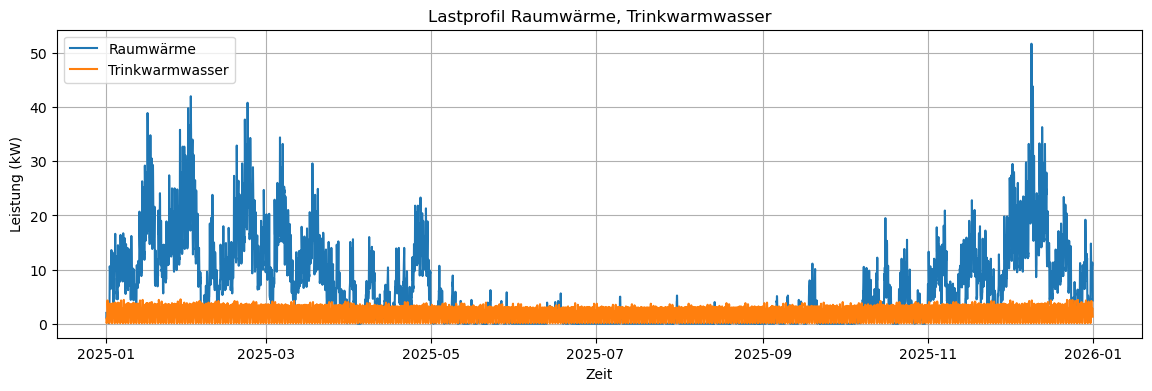

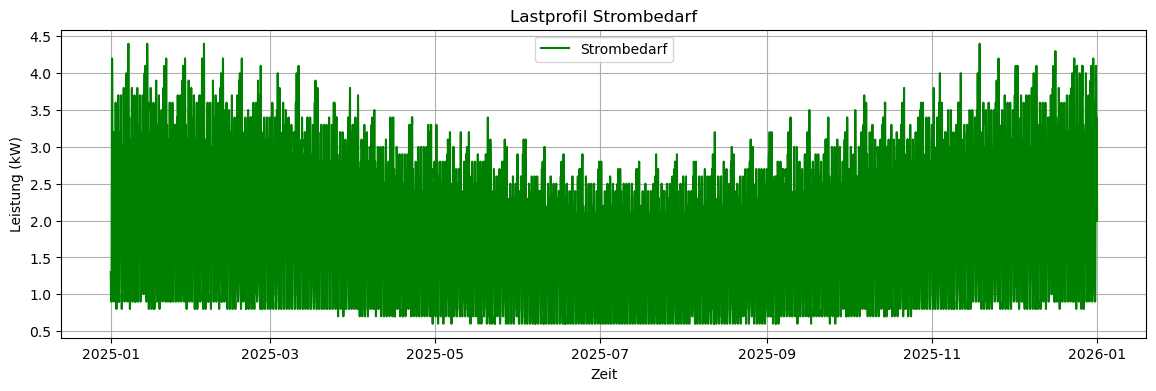

In [56]:
# ------------------------------------------------------------
# Plot der Lasten
# ------------------------------------------------------------
# Wärmebedarf
plt.figure(figsize=(14,4))
plt.plot(df["Zeit"], df["Raumwaerme (kW)"], label="Raumwärme")
plt.plot(df["Zeit"], df["Trinkwarmwasser (kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme, Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.show()

# Strombedarf
plt.figure(figsize=(14,4))
plt.plot(df["Zeit"], df["Strombedarf (kW)"], label="Strombedarf", color="green")
plt.legend()
plt.title("Lastprofil Strombedarf")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.show()

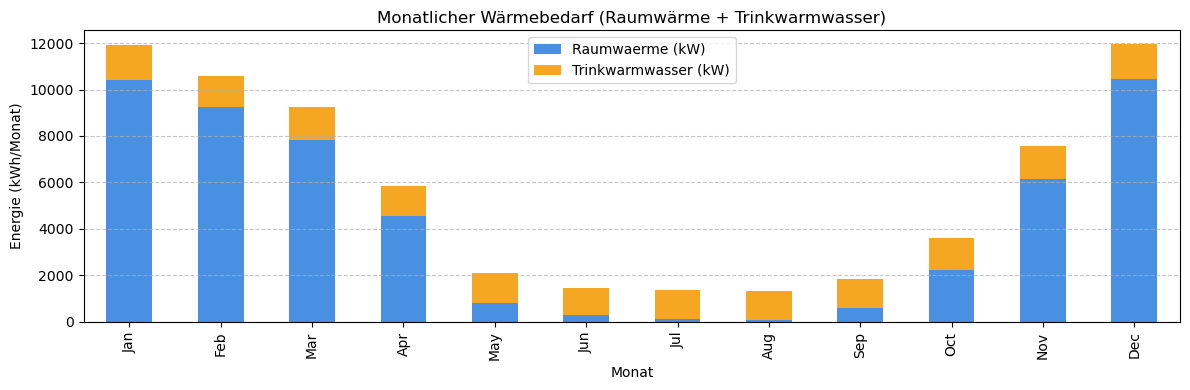

In [57]:
# ------------------------------------------------------------
# Monats-Balkendiagramm statt Linienplot
# ------------------------------------------------------------

df_plot = df.set_index("Zeit")

# Monatswerte berechnen (kWh/Monat)
monthly = df_plot.resample("ME")[["Raumwaerme (kW)", "Trinkwarmwasser (kW)"]].sum()

# Monatsnamen schöner formatieren
monthly.index = monthly.index.strftime("%b")

# Gestapeltes Balkendiagramm (wie in NPro)
ax = monthly.plot(
    kind="bar",
    figsize=(12,4),
    stacked=True,
    color=["#4A90E2", "#F5A623"]  # optionale Farben
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie (kWh/Monat)")
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()




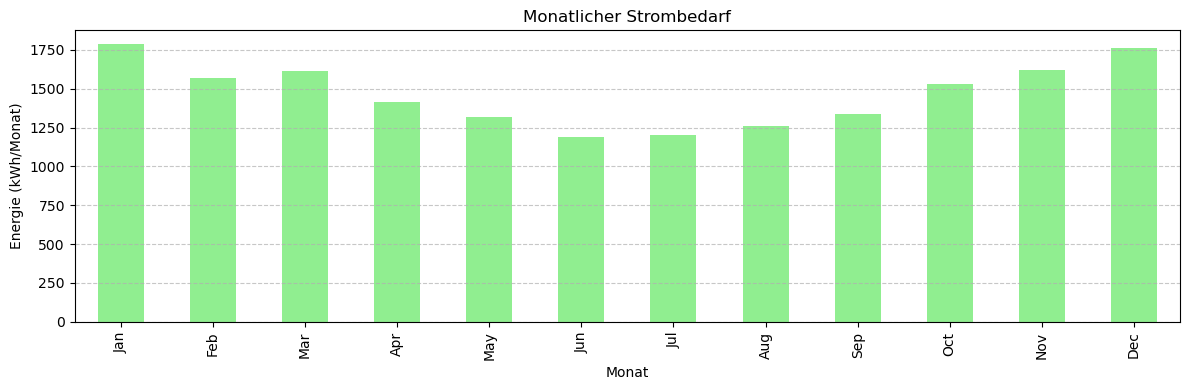

In [58]:
# ------------------------------------------------------------
# Monats-Balkendiagramm Strombedarf
# ------------------------------------------------------------

# Monatswerte berechnen (kWh/Monat)
monthly_elec = df_plot.resample("ME")[["Strombedarf (kW)"]].sum()

# Monatsnamen setzen
monthly_elec.index = monthly_elec.index.strftime("%b")

# Plot
ax = monthly_elec.plot(
    kind="bar",
    figsize=(12,4),
    color="lightgreen",
    legend=False
)

ax.set_title("Monatlicher Strombedarf")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie (kWh/Monat)")
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()


In [59]:
# # ------------------------------------------------------------
# # Erzeugungsprofil Laden - stündlich - renewables.ninja - 2019 Cologne
# # ------------------------------------------------------------
#
# # Wind Erzeugungsprofil
# # Annahmen: Vestas V90 2000, 2019, capacity 1kW, Hub height 80 m
# wind = pd.read_csv(
#     "./Input_Data/ninja_wind_50.9384_6.9600_corrected.csv",
#     skiprows=3,                 # überspringt die Kommentarzeilen
#     parse_dates=["local_time"], # benutze die lokale Zeit
# )
#
# # Index setzen
# wind = wind.set_index("local_time")
#
# # Spalte vereinfachen
# wind = wind.rename(columns={"electricity": "wind_electricity"})
#
# wind.head()


,time,wind_electricity
local_time,,
2019-01-01 01:00:00,2019-01-01 00:00,0.233
2019-01-01 02:00:00,2019-01-01 01:00,0.260
2019-01-01 03:00:00,2019-01-01 02:00,0.282
2019-01-01 04:00:00,2019-01-01 03:00,0.329
2019-01-01 05:00:00,2019-01-01 04:00,0.375


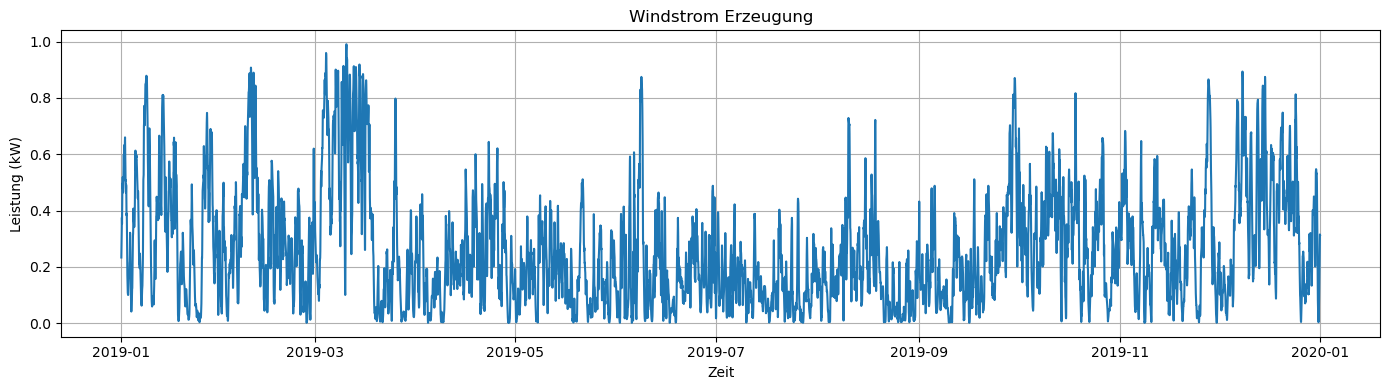

In [60]:
# # Erzeugungsprofil plotten
# plt.figure(figsize=(14,4))
# plt.plot(wind.index, wind["wind_electricity"], label="Wind (kW)")
# plt.title("Windstrom Erzeugung")
# plt.xlabel("Zeit")
# plt.ylabel("Leistung (kW)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [61]:
# PV Erzeugungsprofil
# Annahmen: Dataset MERRA-2 (global), 2019, capacity 1kW, system loss 0.1 , Tilt 35°, Azimuth 180°, included raw data
pv = pd.read_csv(
    "../Input_Data/ninja_pv_50.9384_6.9600_corrected.csv",
    skiprows=3,
    parse_dates=["local_time"],
)

pv = pv.set_index("local_time")

pv = pv.rename(columns={
    "electricity": "pv_electricity",
    "irradiance_direct": "direct",
    "irradiance_diffuse": "diffuse",
    "temperature": "temp"
})

pv.head(100)

,time,pv_electricity,direct,diffuse,temp
local_time,,,,,
2019-01-01 01:00:00,2019-01-01 00:00,0.0,0.0,0.0,6.294
2019-01-01 02:00:00,2019-01-01 01:00,0.0,0.0,0.0,6.003
2019-01-01 03:00:00,2019-01-01 02:00,0.0,0.0,0.0,5.710
2019-01-01 04:00:00,2019-01-01 03:00,0.0,0.0,0.0,5.540
2019-01-01 05:00:00,2019-01-01 04:00,0.0,0.0,0.0,5.458
...,...,...,...,...,...
2019-01-05 00:00:00,2019-01-04 23:00,0.0,0.0,0.0,2.187
2019-01-05 01:00:00,2019-01-05 00:00,0.0,0.0,0.0,2.378
2019-01-05 02:00:00,2019-01-05 01:00,0.0,0.0,0.0,2.531


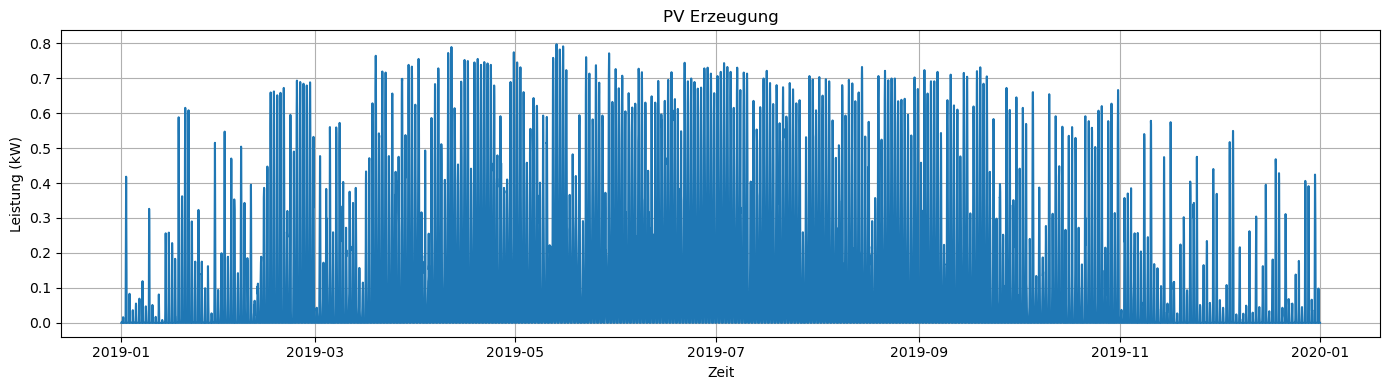

In [62]:
# Erzeugungsprofil PV plotten
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:
# ------------------------------------------------------------
# Außentemperaturdaten laden
# ------------------------------------------------------------

weather = pd.read_csv(
    "../Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv",
    skiprows=3,
    parse_dates=["local_time"]
)

# Index setzen
weather = weather.set_index("local_time")

# Umbenennen: t2m → T_outdoor
weather = weather.rename(columns={"t2m": "T_outdoor"})

# Nur Temperatur extrahieren
T_outdoor = weather["T_outdoor"]

T_outdoor.head()

local_time
2019-01-01 01:00:00    6.294
2019-01-01 02:00:00    6.003
2019-01-01 03:00:00    5.710
2019-01-01 04:00:00    5.540
2019-01-01 05:00:00    5.458
Name: T_outdoor, dtype: float64

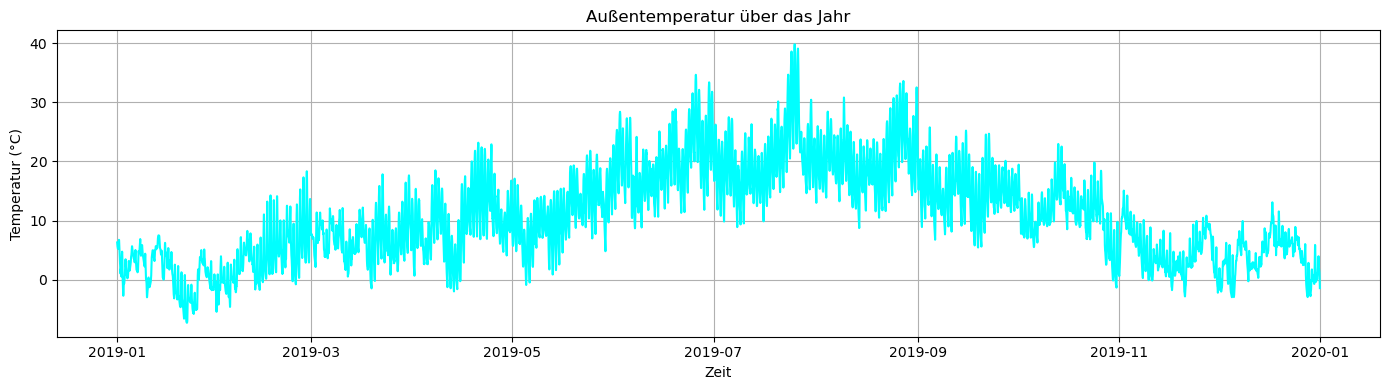

In [64]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [65]:
### Auslegung der Komponenten

In [66]:
#Strom
PV_power = 13 # kWp
grid_power = 70 #kW Hausanschluss Leistung          # stimmt das auch für unser MFH?
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug

#Wärme
Store_height = 1.5 #m
Store_base = 0.4 #m²
Store_T_layers = [60, 56, 52, 48, 44] #°C Temperaturschichten; !! Hier kann die Anzahl und die Temperatur der Schichten angepasst werden !!
Store_T_return = 30 #°C Rücklauftemperatur

HP_power = 65 #kW Wärmepumpenleistung
HE_power = 15 #kW Heizstableistung

In [67]:

# ---------------------------------------------
# Energiesystem
# ---------------------------------------------

# ------------------------------------------------------------
# Elektrisches System
# ------------------------------------------------------------
# # Strombus
n.add("Bus", "electricity")

# Netz-Generator (Strombezug aus dem Netz)
n.add(
    "Generator",
    name="grid_import",
    bus="electricity",
    p_nom=grid_power,
    marginal_cost=grid_cost # €/kwh  # Literaturwert nehmen!
)

# PV-Generator
n.add(
    "Generator",
    name="pv_generation",
    bus="electricity",
    p_nom=PV_power,                 # kW_peak,
    p_max_pu=pv["pv_electricity"].values,
    marginal_cost=0.0                           # verwenden? Literaturdaten
)


# ------------------------------------------------------------
# Stromspeicher
# ------------------------------------------------------------
#
# # Battery-Store
# n.add(
#     "StorageUnit",
#     name = "store_el",
#     bus = "electricity",
#     e_nom_mod = 20.0,             # maximale Speicherkapazität in kWh (Platzhalter)
#     e_nom_extendable = True,
#     e_cyclic = True,
#     standing_loss = 0.01,         # Verluste pro Stunde [%] (Platzhalter)
#     capital_cost = 300.0,         # €/kWh (Platzhalter)
#     lifetime=15,                  # Jahre (Platzhalter)
#     build_year=2025,              # Baujahr (Platzhalter)
#     efficiency_store= 0.95,       #
#     efficiency_dispatch=0.95,
# )


# ------------------------------------------------------------
# Wärmespeicher
# ------------------------------------------------------------
# Konstant geschichteter Speicher:
# - constant="temperature"
# - T_layer: feste Temperaturschichten
# - T_return: Rücklauftemperatur
# - cyclic=True: Speicherzustand am Ende = am Anfang

n.add(
    "HeatStore",
    name="hs_mfh",              # # hs = heat store (Wärmespeicher)
    constant="temperature",
    height=Store_height,                # Höhe [m] (Platzhalter)
    base=Store_base,                  # Grundfläche [m²] → Volumen ~ 4 m³
    T_layer=Store_T_layers,  # Temperaturschichten [°C]
    T_return=Store_T_return,               # Rücklauftemperatur [°C]
    V_initial=[0,0,0,0,0],
    cyclic=True,               # Anfangs- und Endzustand identisch (V_initial)
    T_amb=20.0,                # Umgebungstemperatur des Speichers [°C]
    U_wall=0.2                 # U-Wert der Dämmung [W/(m²*K)] (Platzhalter)
)


# ------------------------------------------------------------
# Wärmepumpe (HeatPump)
# ------------------------------------------------------------

n.add(
    "HeatPump",
    name="hp_mfh",
    bus0="electricity",     # elektrische Seite am Strombus
    heat_store="hs_mfh",    # thermische Seite am Wärmespeicher
    p_nom=HP_power,         # thermische Nennleistung in kW
    T_source=T_outdoor.values,    # Quelltemperatur = Außentemperatur (Luft-Wasser-Wärmepumpe)
    T_max = 65,
    heat_source="air"      # Luft als Quelle
)

# ------------------------------------------------------------
# Elektrischer Heizstab (HeatingElement)
# ------------------------------------------------------------

n.add(
    "HeatingElement",
    name="backup_heater",
    bus0="electricity",
    heat_store="hs_mfh",
    p_nom=HE_power, # elektrische Nennleistung in kW
    efficiency=0.95
)

# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (flow_temperature)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = False

T_vorlauf = 55.0 if use_radiators else 40.0
T_gradient = 1.0 # wie stark die Vorlauftemperatur mit der Außentemp. steigt

# Heizkurve berechnen (PyPSA_heat-Funktion aus der Übung) - hier wird die vorlauftemperatur verwendet!
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor.values)


# ------------------------------------------------------------
# Loads des Energiesystems definieren
# ------------------------------------------------------------
p_el = df["Strombedarf (kW)"].values
p_raumwaerme = df["Raumwaerme (kW)"].values
p_warmwasser = df["Trinkwarmwasser (kW)"].values

# Elektrische Last
n.add(
    "Load",
    name="el_demand",
    bus="electricity",
    p_set=p_el
)

# Raumwärme
n.add(
    "HeatLoad",
    name="Raumwaerme",
    heat_store="hs_mfh",
    p_set=p_raumwaerme,
    T_demand=T_flow
)

# Warmwasser
n.add(
    "HeatLoad",
    name="dhw",
    heat_store="hs_mfh",
    p_set=p_warmwasser,
    T_demand=60.0
)




C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

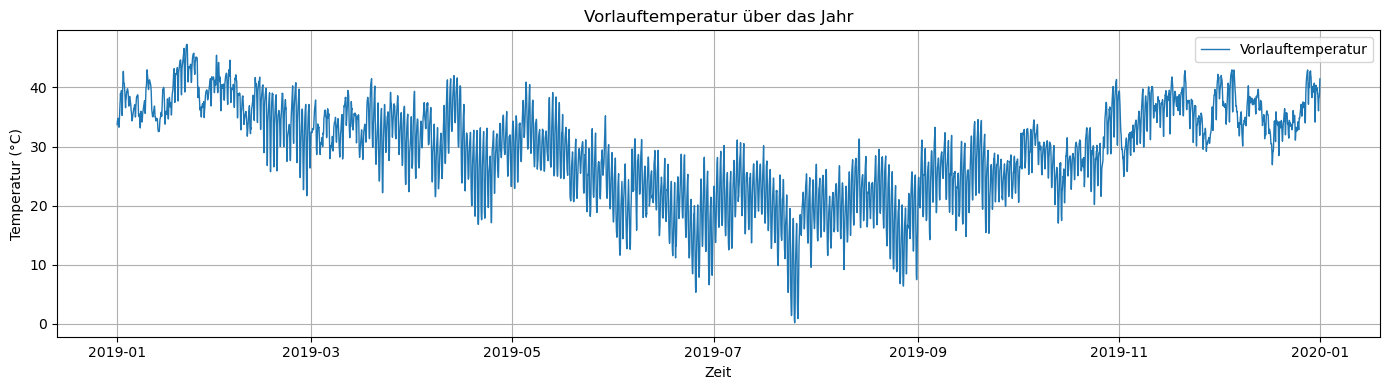

In [68]:
plt.figure(figsize=(14,4))
plt.plot(weather.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

INFO:gurobipy:


Solved in 88321 iterations and 1.08 seconds (1.21 work units)


INFO:gurobipy:Solved in 88321 iterations and 1.08 seconds (1.21 work units)


Optimal objective  1.193369715e+04


INFO:gurobipy:Optimal objective  1.193369715e+04
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 157680 primals, 306600 duals
Objective: 1.19e+04
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs_mfh-fix-volume-upper, HeatStore-hs_mfh-fix-volume-lower, HeatStore-hs_mfh-layer_balance, HeatStore-hs_mfh-internal-lower, HeatingElement-backup_heater-fix-p-lower, HeatingElement-backup_heater-fix-p-upper, HeatPump-hp_mfh-fix-p-lower, HeatPump-hp_mfh-fix-p-upper, HeatPump-hp_mfh-fix-p-layer-lower, HeatPump-hp_mfh-fix-p-layer-upper were not assigned to the network.


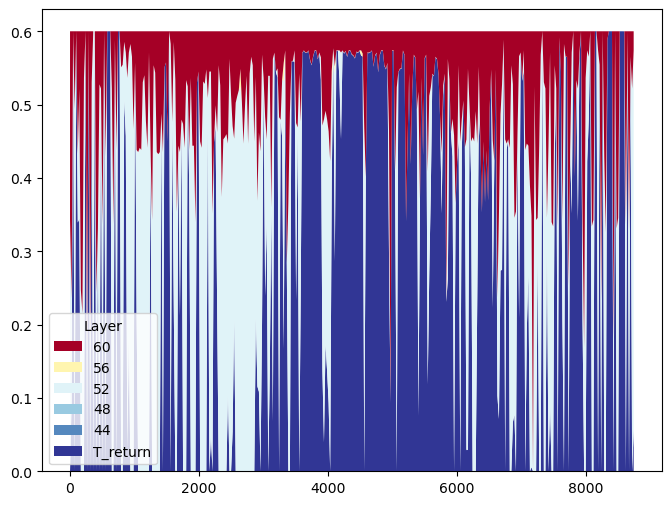

In [69]:
# ------------------------------------------------------------
# Optimierung & Plot
# ------------------------------------------------------------
#Hello
n.optimize(solver_name="gurobi")


sns_to_plot = snapshots[::24]   # jeden Tag ein Punkt
ph.plot.plot_stratified_heat_store(
    n,
    hs="hs_mfh",
    sns=sns_to_plot
)


In [70]:
# ============================================================
# Energiesystem: Ergebnisse & Kennzahlen
# ============================================================

print("====================================")
print("Energiesystem – Überblick")
print("====================================")

# ------------------------------------------------------------
# 1) Komponenten-Auslegung (Nennleistungen)
# ------------------------------------------------------------

print("\n--- Komponenten ---")

# Generatoren (klassisch)
if "pv_generation" in n.generators.index:
    print("PV Leistung [kW]:", n.generators.loc["pv_generation", "p_nom"])

if "grid_import" in n.generators.index:
    print("Netzanschluss [kW]:", n.generators.loc["grid_import", "p_nom"])

# PyPSA-Heat Komponenten (generic API)
hp_df = n.df("HeatPump")
he_df = n.df("HeatingElement")
hs_df = n.df("HeatStore")

if "hp_mfh" in hp_df.index:
    # je nach Version p_nom oder p_nom_opt (wenn extendable)
    if "p_nom_opt" in hp_df.columns:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom_opt"])
    else:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom"])

if "backup_heater" in he_df.index:
    if "p_nom_opt" in he_df.columns:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom_opt"])
    else:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom"])

# Wärmespeicher-Auslegung (Geometrie / Dämmung)
if "hs_mfh" in hs_df.index:
    print("\n--- Wärmespeicher (hs_mfh) ---")
    for col in ["height", "base", "U_wall", "T_return", "T_amb"]:
        if col in hs_df.columns:
            print(f"{col}: {hs_df.loc['hs_mfh', col]}")


Energiesystem – Überblick

--- Komponenten ---
PV Leistung [kW]: 13.0
Netzanschluss [kW]: 70.0
Wärmepumpe Leistung [kW_th]: 65.0
Heizstab Leistung [kW_el]: 15.0

--- Wärmespeicher (hs_mfh) ---
height: 1.5
base: 0.4
U_wall: 0.2
T_return: 30.0
T_amb: 20.0



Wärmepumpe – Auswertung (hp_mfh)


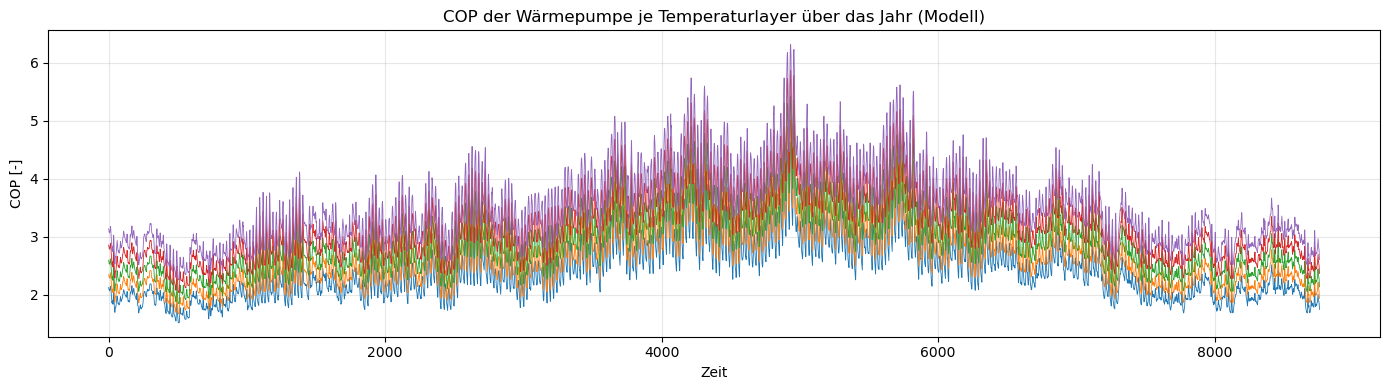


--- Auslegung ---
Thermische Nennleistung p_nom: 65.00 kW_th

--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---
COP Mittelwert: 2.72
COP Median:     2.59
COP Minimum:    1.82
COP Maximum:    5.81

--- Jahresenergien ---
WP Stromverbrauch: 26201.83 kWh_el/a
WP Wärmeerzeugung: 64548.15 kWh_th/a

--- JAZ ---
JAZ_HP (Q_hp / E_hp): 2.463


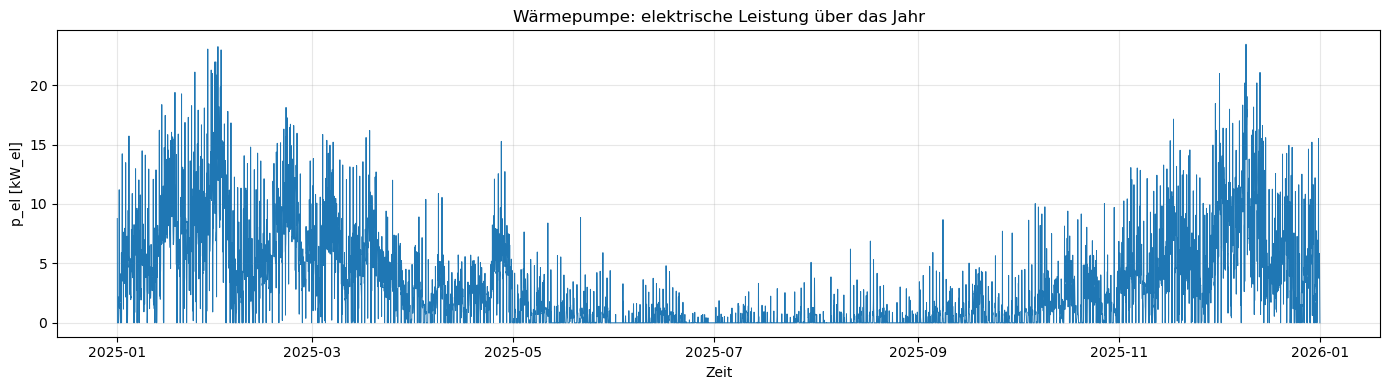

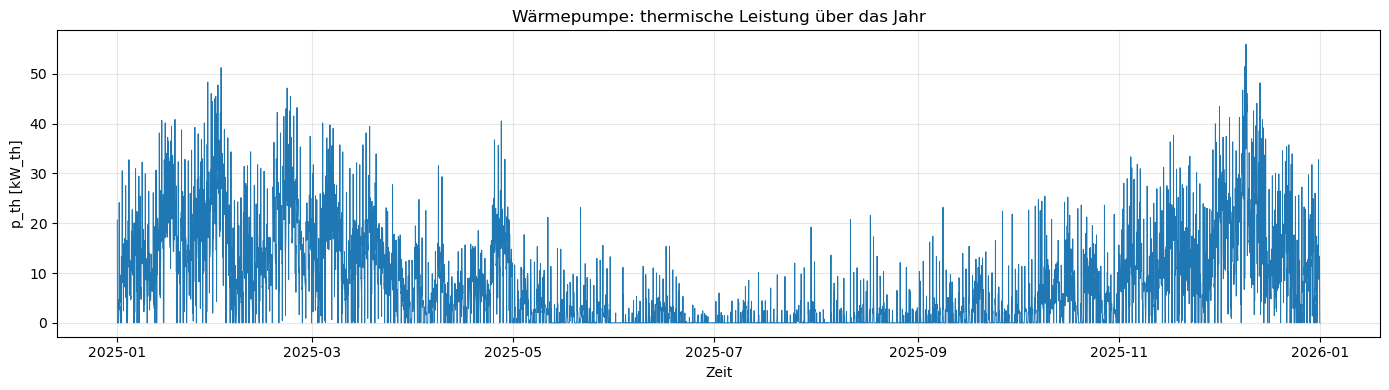

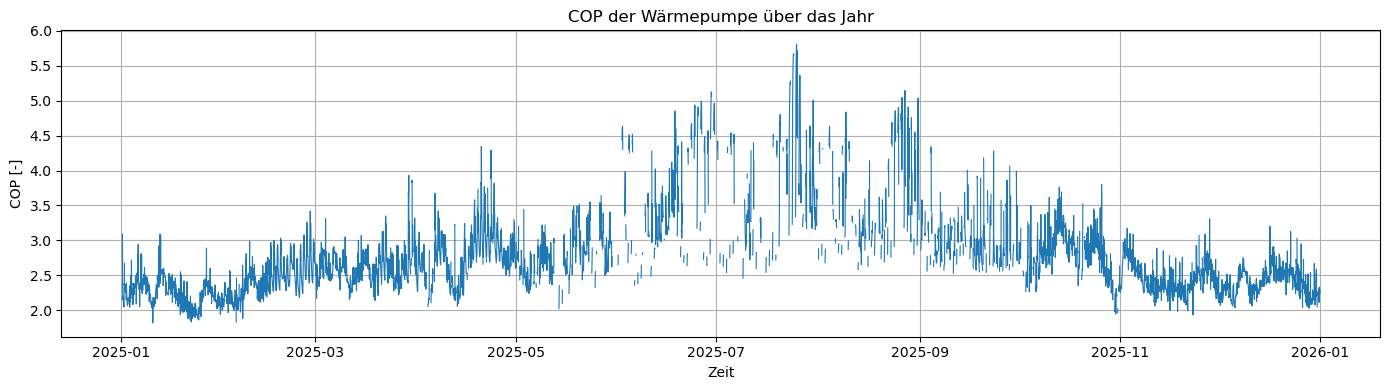

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


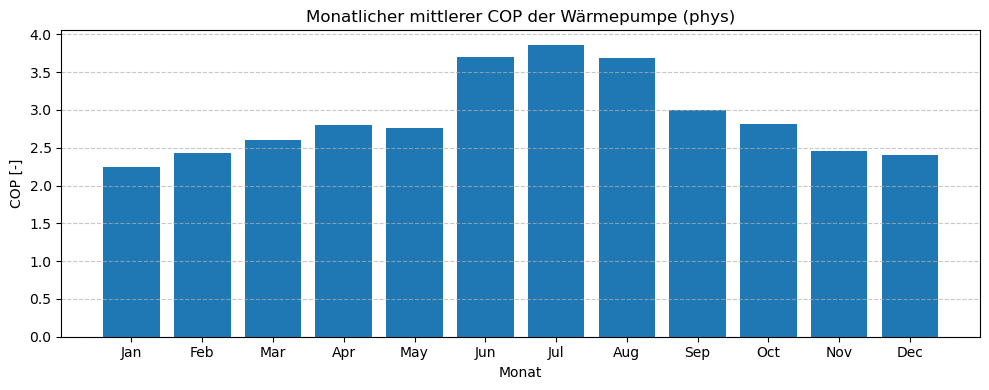

In [71]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ (Layer-korrekt)
# ============================================================

hp_name = "hp_mfh"

hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

# hp_t =
#   "p_heat":  Zeitreihe(n),
#   "p_elec":  Zeitreihe(n),
#   "COP":     Zeitreihe(n),
#   ...
#   }

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere Temperaturschichten enthalten
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# kurzer Einschub Plot: COP je Temperaturlayer darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr (Modell)")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr (Modell)")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================
# jetzt weiter mit Code
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = pd.DatetimeIndex(df["Zeit"])   # df = Lastprofil (Raumwärme, Trinkwarmwasser, Strom)
                                            # Zeitspalte aus meinem Lastprofil nehmen und nutze diese hier weiter

# p_heat / p_elec: Gesamtleistung (Summe über Layer, falls nötig)

# Typabfrage mit isinstance(..) = ist p_th_model ein DataFrame (mehere Layer)
# wenn p_th_model ein DataFrame ist, dann summe über alle Layer, sonst nur über 1. Layer - damit # der Layer anpassbar
p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
# mean(axis=1) bedutet arithmetischer Mittelwert aller Layer-COPs pro Stunde
# Das ist der gemittelte Modell-COP über alle Temperaturschichten.
# cop_model_mean ist der aus dem Modell resultierende, über alle Temperaturlayer gemittelte COP und dient ausschließlich der qualitativen Interpretation, nicht der energetischen Bewertung.
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

# Datetime-Series
# p_el_s = die stündliche elektrische Leistung der WP
# np.asarray(p_el_s, dtype=float) erzwingt numpy-Array-Konvertierung (robuste Statistik)
# pd.series baut daraus eine Zeitreihe - jeder Wert bekommt einen Zeitstempel aus dem time_index
# „Ich nehme Daten aus der Simulation und mache daraus eine saubere, zeitlich zuordenbare Serie.“
# p_el_ts = elektrische Leistung der Wp pro std in pd.series
p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# Physikalischer COP aus Q/P
# Betriebs COP der WP pro stunde
# p_th_ts = Wärmeleistung der WP (kW_th) pro Stunde
# p_el_ts = Elektrische Leistung der WP (kW_el) pro Stunde
# p_el_ts.replace(0, np.nan) = ersetzt alle Stellen, wo der Stromverbrauch 0 ist, durch NaN.
# „COP ist in diesen Stunden nicht definiert (weil WP aus).“
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
# wenn es die Spalte p_nom gibt → Wert auslesen
# sonst → None, Schutz falls das Modell p_nom nicht gesetzt ist
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP phys) ---
# np.nanmean(...), np.nanmedian(...), etc. sind numpy-Funktionen
# float() wandelt Ergebnis in Python Scalar für print(..), weiterrechnen usw.
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a
# .values → NumPy-Array der Zahlen, np.nansum(...) → summiert alles, ignoriert NaNs, float(...) → macht daraus eine normale Zahl

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# --- Ergebnis Plots:  ---

# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Monatsmittel COP (phys) ---
cop_monthly = cop_phys_ts.resample("ME").mean()
cop_monthly.index = cop_monthly.index.strftime("%b")

plt.figure(figsize=(10,4))
plt.bar(cop_monthly.index, cop_monthly.values)
plt.title("Monatlicher mittlerer COP der Wärmepumpe (phys)")
plt.xlabel("Monat")
plt.ylabel("COP [-]")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



